# Notebook 3 — The parabola

*SWC ENC 2026 · ephys-one module*

This is the core of the module. Notebook 2 left us with two curves and two formulas:

$$\langle I\rangle(t) = N\, i\, p(t), \qquad \sigma^2(t) = N\, i^2\, p(t)\,(1-p(t)).$$

Three unknowns — $N$, $i$ and $p(t)$ — but $p(t)$ is a whole *function* that changes
from sample to sample, while $N$ and $i$ are two fixed numbers. The trick is to get
rid of $p$ altogether.

**In this notebook you will:**
1. Eliminate $p$ and discover that variance against mean is a **parabola**.
2. Learn to **read** the parabola: slope → $i$, where it closes → $N$.
3. **Fit** it by least squares and recover $N$, $i$ and the maximum open
   probability $p_{max}$.
4. Package the whole analysis into one function and test it on fresh patches.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picopatch as pp

exp = pp.make_experiment(N=1000, i=1.0, n_sweeps=300, seed=0)     # the same patch as Notebook 2
mean, var = pp.isochrone_stats(exp.sweeps)

## 1. Getting rid of p

From the first formula, $p = \langle I\rangle / (N i)$. Substitute into the second:

$$\sigma^2 = N i^2 \cdot \frac{\langle I\rangle}{N i}\left(1 - \frac{\langle I\rangle}{N i}\right)
 = i\,\langle I\rangle - \frac{\langle I\rangle^2}{N}.$$

$$\boxed{\;\sigma^2 = i\,\langle I\rangle - \frac{\langle I\rangle^2}{N}\;}$$

Time has disappeared. At every isochrone, whatever $p$ happens to be, the pair
(mean, variance) must sit on this one curve — a parabola through the origin whose
shape depends only on $i$ and $N$. So instead of plotting mean and variance against
*time*, plot them against *each other*. Here's the construction, step by step: pick a
few isochrones on the time plots (left), and move each pair of values to a dot in the
variance–mean plane (right).

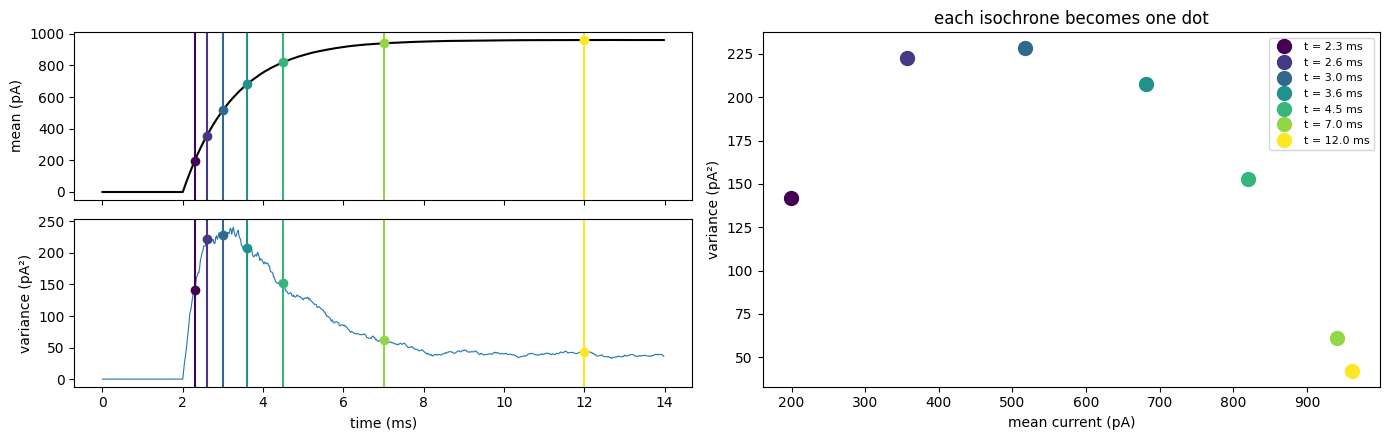

In [2]:
picks_ms = [2.3, 2.6, 3.0, 3.6, 4.5, 7.0, 12.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(picks_ms)))

fig = plt.figure(figsize=(14, 4.5))
ax_m = plt.subplot2grid((2, 2), (0, 0)); ax_v = plt.subplot2grid((2, 2), (1, 0), sharex=ax_m)
ax_p = plt.subplot2grid((2, 2), (0, 1), rowspan=2)
ax_m.plot(exp.t_ms, mean, "k"); ax_v.plot(exp.t_ms, var, color="tab:blue", lw=0.8)
for tm, c in zip(picks_ms, colors):
    k = int(np.argmin(np.abs(exp.t_ms - tm)))
    ax_m.axvline(tm, color=c, lw=1.5); ax_v.axvline(tm, color=c, lw=1.5)
    ax_m.plot(tm, mean[k], "o", color=c); ax_v.plot(tm, var[k], "o", color=c)
    ax_p.plot(mean[k], var[k], "o", color=c, ms=10, label=f"t = {tm} ms")
ax_m.set_ylabel("mean (pA)"); ax_v.set_ylabel("variance (pA²)"); ax_v.set_xlabel("time (ms)")
ax_m.tick_params(labelbottom=False)
ax_p.set_xlabel("mean current (pA)"); ax_p.set_ylabel("variance (pA²)")
ax_p.set_title("each isochrone becomes one dot"); ax_p.legend(fontsize=8)
plt.tight_layout(); plt.show()

Now do it for *every* isochrone — all 700 time points — and colour the dots by time:

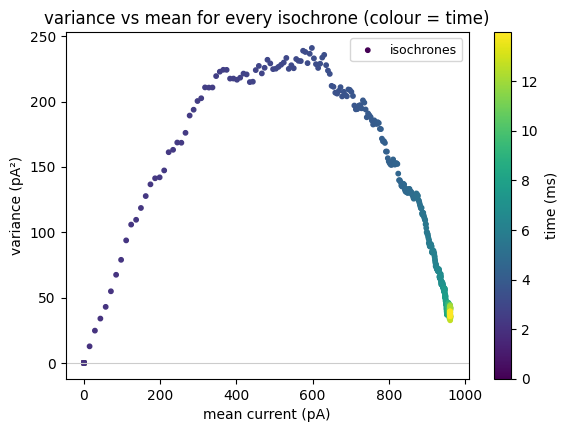

In [3]:
pp.plotting.plot_variance_mean(mean, var, t_ms=exp.t_ms,
                               title="variance vs mean for every isochrone (colour = time)")
plt.show()

A parabola. Early times (purple) start at the origin and run up the left arm as the
channels open; late times (yellow) pile up near the plateau on the right. The points
are a bit scattered because each variance is estimated from only 300 sweeps, but the
shape is unmistakable.

## 2. Reading the parabola

Every feature of $\sigma^2 = i\langle I\rangle - \langle I\rangle^2/N$ means something:

- **Near the origin** the quadratic term is negligible and $\sigma^2 \approx i\,\langle I\rangle$:
  the **initial slope is the unitary current** $i$. (Intuition: when few channels are
  open, each opening adds $i$ to the mean *and* roughly $i^2$ to the variance.)
- The variance **returns to zero** when $i\langle I\rangle = \langle I\rangle^2/N$,
  i.e. at $\langle I\rangle = i N$: every channel open, nothing left to fluctuate.
  So the right-hand root tells you the **maximum possible current**, and dividing by
  $i$ gives $N$.
- The **peak** sits halfway, at $\langle I\rangle = iN/2$ (half the channels open),
  with height $i^2 N / 4$.

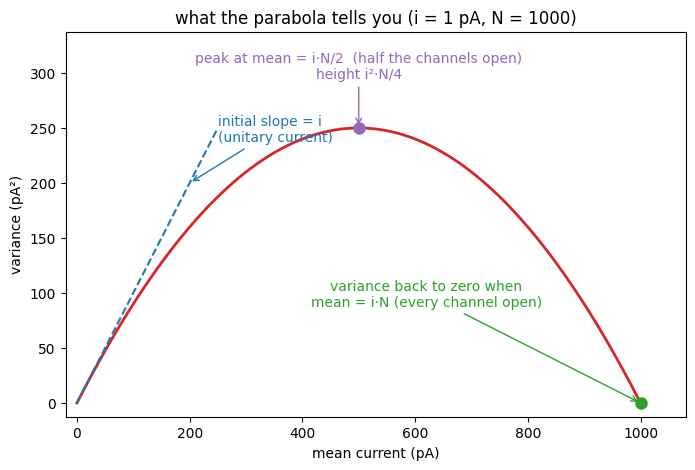

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
pp.plotting.annotate_parabola(ax, i=1.0, N=1000)
ax.set_title("what the parabola tells you (i = 1 pA, N = 1000)"); plt.show()

To get a feel for how the two parameters shape the curve, here is what changes when
you vary one at a time:

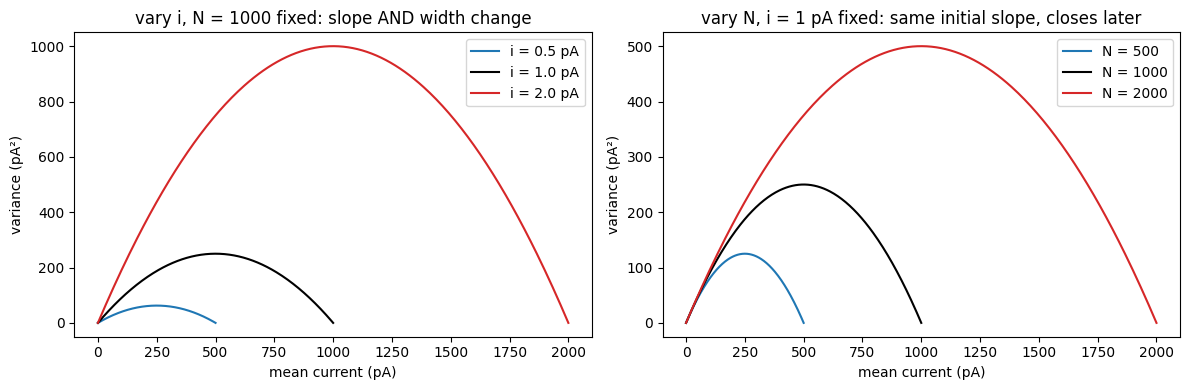

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
m = np.linspace(0, 1000, 300)
for i_u, c in zip([0.5, 1.0, 2.0], ["tab:blue", "k", "tab:red"]):
    N = 1000
    mm = np.linspace(0, i_u * N, 300)
    axes[0].plot(mm, i_u * mm - mm**2 / N, color=c, label=f"i = {i_u} pA")
axes[0].set_title("vary i, N = 1000 fixed: slope AND width change"); axes[0].legend()
for N, c in zip([500, 1000, 2000], ["tab:blue", "k", "tab:red"]):
    mm = np.linspace(0, 1.0 * N, 300)
    axes[1].plot(mm, 1.0 * mm - mm**2 / N, color=c, label=f"N = {N}")
axes[1].set_title("vary N, i = 1 pA fixed: same initial slope, closes later"); axes[1].legend()
for ax in axes:
    ax.set_xlabel("mean current (pA)"); ax.set_ylabel("variance (pA²)")
plt.tight_layout(); plt.show()

**Exercise 1** *(~5 min)*. Estimate $i$ **from the initial slope alone**. Complete
`initial_slope`: keep the isochrones whose mean is below `fraction` of the largest
mean (the near-linear start of the parabola) and fit a line through the origin,
$\sigma^2 = i\,\langle I\rangle$. For a line through the origin the least-squares slope
is $\sum m\,v \,/\, \sum m^2$.

> **Check / unstuck.** You should get $i \approx 1$ pA (within ~10%). Stuck?
> `pp.fit_slope_only(mean, var)`.

unitary current from the initial slope: i = 0.71 pA   (truth 1.0 pA)


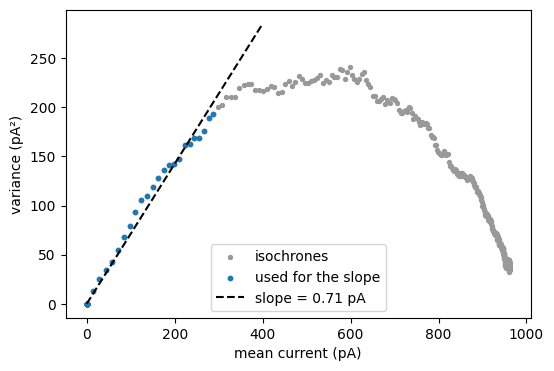

In [6]:
def initial_slope(mean, var, fraction=0.3):
    keep = mean <= fraction * mean.max()
    return np.sum(mean[keep] * var[keep]) / np.sum(mean[keep] ** 2)

i_slope = initial_slope(mean, var)
print(f"unitary current from the initial slope: i = {i_slope:.2f} pA   (truth 1.0 pA)")

plt.figure(figsize=(6, 4))
plt.scatter(mean, var, s=8, color="0.6", label="isochrones")
keep = mean <= 0.3 * mean.max()
plt.scatter(mean[keep], var[keep], s=10, color="tab:blue", label="used for the slope")
mm = np.linspace(0, 400, 10); plt.plot(mm, i_slope * mm, "k--", label=f"slope = {i_slope:.2f} pA")
plt.xlabel("mean current (pA)"); plt.ylabel("variance (pA²)"); plt.legend(); plt.show()

## 3. Fitting the whole parabola

The slope alone wastes most of the data. Better: fit the full curve to all the dots at
once. This looks like a nonlinear problem, but it isn't. Write $a = i$ and $b = 1/N$:

$$\sigma^2 = a\,\langle I\rangle + b\,(-\langle I\rangle^2).$$

The variance is a **linear combination of two known regressors**, $\langle I\rangle$
and $-\langle I\rangle^2$, with no intercept. That is ordinary least squares with a
two-column design matrix, solved in one line by `np.linalg.lstsq`. Then $i = a$ and
$N = 1/b$.

<details>
<summary><b>▸ Go deeper: the least-squares solution (optional)</b></summary>

Stack the isochrones: $\mathbf{v} = (\sigma^2_1, \ldots, \sigma^2_T)^\top$ and the
design matrix $A$ with rows $(\langle I\rangle_t,\; -\langle I\rangle_t^2)$. We want
$\boldsymbol\theta = (a, b)^\top$ minimising $\|\mathbf{v} - A\boldsymbol\theta\|^2$.
Setting the gradient to zero gives the normal equations
$A^\top A\, \boldsymbol\theta = A^\top \mathbf{v}$, so
$\boldsymbol\theta = (A^\top A)^{-1} A^\top \mathbf{v}$ — which is what `lstsq`
computes (more stably). Exercise 1 was the one-column version of the same thing.

Two refinements the paper doesn't bother with, and nor will we: (1) each variance
estimate has its own uncertainty, roughly $\sigma^2\sqrt{2/(n_{sweeps}-1)}$, so a
*weighted* fit would down-weight the noisier high-variance points; (2) in Notebook 4
we add a constant (the background noise variance) as a third term.
</details>

**Exercise 2** *(~8 min)*. Complete `fit_parabola`: build the design matrix with
columns `mean` and `-mean**2`, solve with `np.linalg.lstsq(A, var, rcond=None)`, and
return `i` and `N`.

> **Check / unstuck.** Expect $i \approx 1.0$ pA and $N \approx 1000$, both within a
> few percent. Stuck? `pp.fit_parabola(mean, var)` returns an object with `.i`, `.N`.

fit:   i = 0.954 pA,  N = 1054
truth: i = 1.000 pA,  N = 1000


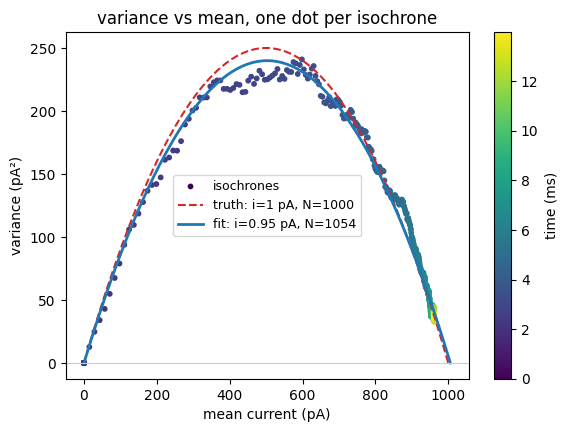

In [7]:
def fit_parabola(mean, var):
    A = np.column_stack([mean, -mean**2])
    (a, b), *_ = np.linalg.lstsq(A, var, rcond=None)
    return a, 1.0 / b

i_hat, N_hat = fit_parabola(mean, var)
print(f"fit:   i = {i_hat:.3f} pA,  N = {N_hat:.0f}")
print(f"truth: i = {exp.truth.i:.3f} pA,  N = {exp.truth.N}")

fit = pp.fit_parabola(mean, var)          # same numbers, packaged for plotting
pp.plotting.plot_variance_mean(mean, var, fit=fit, truth=exp.truth, t_ms=exp.t_ms)
plt.show()

### The maximum open probability

With $i$ and $N$ in hand, the first formula gives the open probability at *every*
time point, $p(t) = \langle I\rangle(t) / (iN)$. Its largest value is the
**maximum open probability** reached in the experiment, $p_{max}$ — the third number
noise analysis delivers, and one you cannot get from the mean current alone (a
plateau of 960 pA could be 1000 channels at $p = 0.96$ or 2000 channels at
$p = 0.48$; only the fluctuations can tell).

**Exercise 3** *(~4 min)*. Compute $p(t)$ from your fit and $p_{max}$, and compare
with the true $p(t)$ in `exp.truth.p_open`.

> **Check / unstuck.** $p_{max} \approx 0.96$; the two curves should overlap.

p_max = 0.956   (truth 0.961)


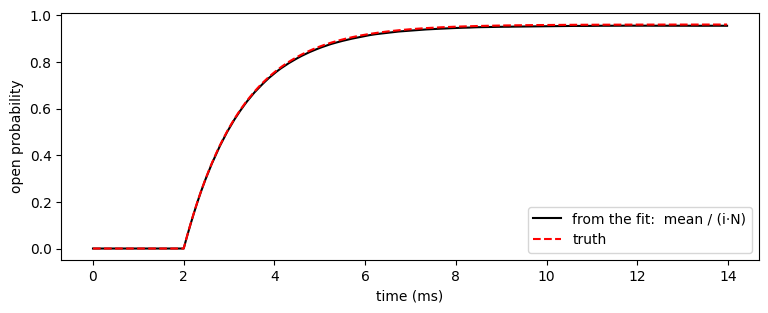

In [8]:
p_t = mean / (i_hat * N_hat)
p_max = p_t.max()
print(f"p_max = {p_max:.3f}   (truth {exp.truth.p_max:.3f})")

plt.figure(figsize=(9, 3.2))
plt.plot(exp.t_ms, p_t, "k", label="from the fit:  mean / (i·N)")
plt.plot(exp.t_ms, exp.truth.p_open, "r--", label="truth")
plt.xlabel("time (ms)"); plt.ylabel("open probability"); plt.legend(); plt.show()

## 4. The whole analysis in one function

You now have every piece. Put them together into `count_channels(sweeps)` and try it
on patches you haven't seen. Below we simulate six patches with different $N$ and $i$
and compare your estimates with the truth.

truth N=  100 i=2.00   ->   fit N=    103  i=1.95  p_max=0.96
truth N=  300 i=0.50   ->   fit N=    300  i=0.50  p_max=0.96
truth N= 1000 i=1.00   ->   fit N=   1086  i=0.93  p_max=0.96


truth N= 2000 i=1.50   ->   fit N=   1953  i=1.53  p_max=0.96
truth N= 5000 i=0.80   ->   fit N=   5053  i=0.79  p_max=0.96


truth N=   50 i=4.00   ->   fit N=     50  i=4.02  p_max=0.96


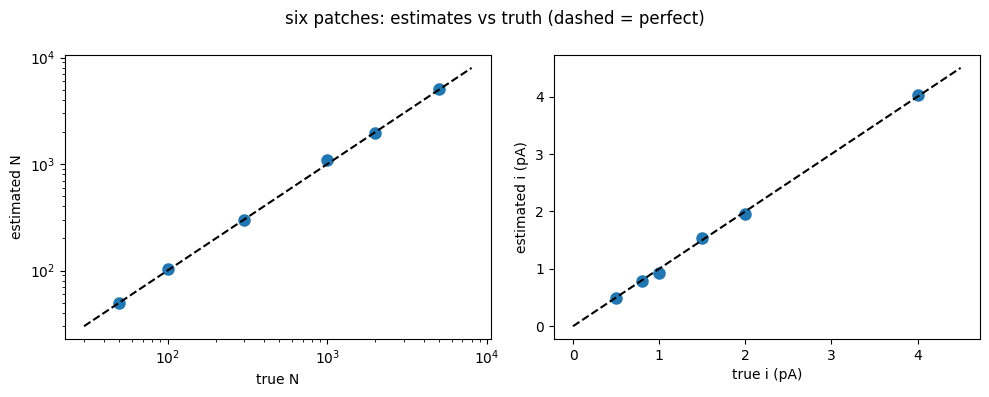

In [9]:
def count_channels(sweeps):
    mean, var = pp.isochrone_stats(sweeps)
    i, N = fit_parabola(mean, var)
    p_max = mean.max() / (i * N)
    return i, N, p_max

truths = [(100, 2.0), (300, 0.5), (1000, 1.0), (2000, 1.5), (5000, 0.8), (50, 4.0)]
rows = []
for k, (N_true, i_true) in enumerate(truths):
    e = pp.make_experiment(N=N_true, i=i_true, n_sweeps=300, seed=10 + k)
    rows.append((N_true, i_true, *count_channels(e.sweeps)))
    print(f"truth N={N_true:5d} i={i_true:.2f}   ->   fit N={rows[-1][3]:7.0f}  i={rows[-1][2]:.2f}  p_max={rows[-1][4]:.2f}")

rows = np.array(rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].loglog(rows[:, 0], rows[:, 3], "o", ms=8); axes[0].plot([30, 8000], [30, 8000], "k--")
axes[0].set_xlabel("true N"); axes[0].set_ylabel("estimated N")
axes[1].plot(rows[:, 1], rows[:, 2], "o", ms=8); axes[1].plot([0, 4.5], [0, 4.5], "k--")
axes[1].set_xlabel("true i (pA)"); axes[1].set_ylabel("estimated i (pA)")
plt.suptitle("six patches: estimates vs truth (dashed = perfect)"); plt.tight_layout(); plt.show()

**Where we are.** This is the complete basic analysis: sweeps → isochrone mean and
variance → variance-vs-mean parabola → least-squares fit → $N$, $i$, $p_{max}$. On
ideal data it works to within a few percent from 300 sweeps.

Real data are not ideal. Notebooks **4–7 are independent**: each takes one way a
recording departs from this ideal — background noise and rundown (4), a parabola you
can only partly reach (5), the amplifier's low-pass filter (6), or a different
experiment altogether, steady-state noise (7) — and shows what it does to the
parabola and how to cope. Do them in whatever order suits; Notebook 8 scores the
result.